In [35]:
import os
import re
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

In [36]:
base_dir = Path(r"C:\NNDL Lab Proj\KTH")
dataset_path = base_dir / "Dataset" if (base_dir / "Dataset").exists() else base_dir

classes = [
    "walking",
    "running",
    "handwaving",
    "handclapping"
]

print("Dataset path:", dataset_path)
print(classes)

Dataset path: C:\NNDL Lab Proj\KTH\Dataset
['walking', 'running', 'handwaving', 'handclapping']


In [37]:
video_paths = []
labels = []

for label, class_name in enumerate(classes):

    class_path = dataset_path / class_name

    for video_file in sorted(class_path.glob("*.avi")):
        video_paths.append(video_file)
        labels.append(label)

print("Total videos:", len(video_paths))
print("Total labels:", len(labels))

print("\nFirst 5 videos:")
for i in range(5):
    print(video_paths[i], "->", labels[i])

Total videos: 399
Total labels: 399

First 5 videos:
C:\NNDL Lab Proj\KTH\Dataset\walking\person01_walking_d1_uncomp.avi -> 0
C:\NNDL Lab Proj\KTH\Dataset\walking\person01_walking_d2_uncomp.avi -> 0
C:\NNDL Lab Proj\KTH\Dataset\walking\person01_walking_d3_uncomp.avi -> 0
C:\NNDL Lab Proj\KTH\Dataset\walking\person01_walking_d4_uncomp.avi -> 0
C:\NNDL Lab Proj\KTH\Dataset\walking\person02_walking_d1_uncomp.avi -> 0


In [38]:
class_counts = Counter(labels)

for class_id, class_name in enumerate(classes):
    print(f"{class_name}: {class_counts[class_id]}")

walking: 100
running: 100
handwaving: 100
handclapping: 99


In [39]:
person_ids = []

for path in video_paths:
    match = re.search(r"person(\d+)", path.name)
    person_ids.append(int(match.group(1)))

unique_persons = sorted(set(person_ids))

print("Number of persons:", len(unique_persons))
print("Persons:", unique_persons)

Number of persons: 25
Persons: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]


In [40]:
train_persons = [11, 12, 13, 14, 15, 16, 17, 18]

val_persons = [19, 20, 21, 23, 24, 25, 1, 4]

test_persons = [22, 2, 3, 5, 6, 7, 8, 9, 10]

print("Train persons:", train_persons)
print("Validation persons:", val_persons)
print("Test persons:", test_persons)

Train persons: [11, 12, 13, 14, 15, 16, 17, 18]
Validation persons: [19, 20, 21, 23, 24, 25, 1, 4]
Test persons: [22, 2, 3, 5, 6, 7, 8, 9, 10]


In [41]:
train_videos = []
train_labels = []

val_videos = []
val_labels = []

test_videos = []
test_labels = []

for video_path, label, person_id in zip(video_paths, labels, person_ids):

    if person_id in train_persons:
        train_videos.append(video_path)
        train_labels.append(label)

    elif person_id in val_persons:
        val_videos.append(video_path)
        val_labels.append(label)

    elif person_id in test_persons:
        test_videos.append(video_path)
        test_labels.append(label)


print("Training videos:", len(train_videos))
print("Validation videos:", len(val_videos))
print("Testing videos:", len(test_videos))

Training videos: 127
Validation videos: 128
Testing videos: 144


In [42]:
print("TRAIN:")
print(Counter(train_labels))

print("\nVALIDATION:")
print(Counter(val_labels))

print("\nTEST:")
print(Counter(test_labels))

TRAIN:
Counter({0: 32, 1: 32, 2: 32, 3: 31})

VALIDATION:
Counter({0: 32, 1: 32, 2: 32, 3: 32})

TEST:
Counter({0: 36, 1: 36, 2: 36, 3: 36})


In [43]:
class KTHDataset(Dataset):

    def __init__(self, video_paths, labels,
                 num_frames=16,
                 frame_step=6,
                 image_size=112):

        self.video_paths = video_paths
        self.labels = labels
        self.num_frames = num_frames
        self.frame_step = frame_step
        self.image_size = image_size

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, index):

        video_path = self.video_paths[index]
        label = self.labels[index]

        cap = cv2.VideoCapture(str(video_path))

        frames = []

        sample_indices = np.arange(
            0,
            self.num_frames * self.frame_step,
            self.frame_step
        )

        for frame_index in sample_indices:

            cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_index))

            ret, frame = cap.read()

            if not ret:
                cap.release()
                raise RuntimeError(
                    f"Could not read frame {frame_index} "
                    f"from {video_path}"
                )

            # BGR -> RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # Resize
            frame = cv2.resize(
                frame,
                (self.image_size, self.image_size)
            )

            # Normalize 0-255 -> 0-1
            frame = frame.astype(np.float32) / 255.0

            # HWC -> CHW
            frame = torch.from_numpy(frame).permute(2, 0, 1)

            frames.append(frame)

        cap.release()

        # [16, 3, 112, 112]
        video = torch.stack(frames)

        return video, torch.tensor(label, dtype=torch.long)

In [44]:
train_dataset = KTHDataset(
    train_videos,
    train_labels
)

print("Dataset size:", len(train_dataset))

Dataset size: 127


In [45]:
video, label = train_dataset[0]

print("Video shape:", video.shape)
print("Label:", label)
print("Video dtype:", video.dtype)
print("Min:", video.min().item())
print("Max:", video.max().item())

Video shape: torch.Size([16, 3, 112, 112])
Label: tensor(0)
Video dtype: torch.float32
Min: 0.08627451211214066
Max: 1.0


In [46]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

print("Number of batches:", len(train_loader))

Number of batches: 32


In [47]:
videos, labels = next(iter(train_loader))

print("Videos shape:", videos.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Videos shape: torch.Size([4, 16, 3, 112, 112])
Labels shape: torch.Size([4])
Labels: tensor([0, 2, 3, 1])


### Model Definition (FIXED - with BatchNorm)

**Root Cause of Original Failure:** The CNN without BatchNorm suffered from feature collapse.
All 4 classes produced cosine similarity > 0.9999, with 17/128 dead channels.

**Fix:** Added `BatchNorm2d` after each `Conv2d` layer + `Dropout(0.3)` before the classifier.

In [48]:
class CNNFeatureExtractor(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return x


class LRCN(nn.Module):

    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()

        self.cnn = CNNFeatureExtractor()

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):

        # x: [B, T, C, H, W]
        B, T, C, H, W = x.shape

        # Treat every frame as an individual CNN input
        x = x.view(B * T, C, H, W)

        # CNN -> [B*T, 128]
        x = self.cnn(x)

        # Restore temporal sequence
        x = x.view(B, T, 128)

        # LSTM -> temporal features
        output, (hidden, cell) = self.lstm(x)

        # Last hidden state
        x = hidden[-1]

        # Dropout before classification
        x = self.dropout(x)

        # Classification
        x = self.fc(x)

        return x

In [49]:
model = LRCN(num_classes=4)

print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

LRCN(
  (cnn): CNNFeatureExtractor(
    (features): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (12): AdaptiveAvgPool2d(output_size=(1, 1))
    )
  )
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): D

In [50]:
prediction = model(videos)

print("Input shape:", videos.shape)
print("Output shape:", prediction.shape)
print("Output:", prediction)

Input shape: torch.Size([4, 16, 3, 112, 112])
Output shape: torch.Size([4, 4])
Output: tensor([[ 0.0169,  0.0171, -0.0708,  0.0843],
        [ 0.1231, -0.1336,  0.0304,  0.0163],
        [ 0.1144, -0.1767, -0.0767, -0.0320],
        [ 0.2573, -0.2117, -0.1241,  0.0510]], grad_fn=<AddmmBackward0>)


### Overfitting Sanity Test

Must reach 100% accuracy on 4 samples to confirm the model can learn.

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Get one batch with 4 samples
test_videos_batch, test_labels_batch = next(iter(train_loader))
test_videos_batch = test_videos_batch.to(device)
test_labels_batch = test_labels_batch.to(device)
print(f"Labels: {test_labels_batch}")

sanity_model = LRCN(num_classes=4).to(device)
sanity_criterion = nn.CrossEntropyLoss()
sanity_optimizer = torch.optim.Adam(sanity_model.parameters(), lr=0.001)

sanity_model.train()

for step in range(100):

    predictions = sanity_model(test_videos_batch)
    loss = sanity_criterion(predictions, test_labels_batch)

    sanity_optimizer.zero_grad()
    loss.backward()
    sanity_optimizer.step()

    if (step + 1) % 10 == 0:
        predicted = torch.argmax(predictions, dim=1)
        accuracy = (predicted == test_labels_batch).float().mean() * 100

        print(
            f"Step {step+1:3d} | "
            f"Loss: {loss.item():.4f} | "
            f"Accuracy: {accuracy.item():.1f}%"
        )

# Clean up sanity test
del sanity_model, sanity_optimizer, sanity_criterion
del test_videos_batch, test_labels_batch
torch.cuda.empty_cache()

Device: cuda
Labels: tensor([2, 2, 3, 0], device='cuda:0')
Step  10 | Loss: 0.4810 | Accuracy: 75.0%
Step  20 | Loss: 0.0769 | Accuracy: 100.0%
Step  30 | Loss: 0.0154 | Accuracy: 100.0%
Step  40 | Loss: 0.0054 | Accuracy: 100.0%
Step  50 | Loss: 0.0032 | Accuracy: 100.0%
Step  60 | Loss: 0.0048 | Accuracy: 100.0%
Step  70 | Loss: 0.0045 | Accuracy: 100.0%
Step  80 | Loss: 0.0038 | Accuracy: 100.0%
Step  90 | Loss: 0.0017 | Accuracy: 100.0%
Step 100 | Loss: 0.0018 | Accuracy: 100.0%


### Training

In [52]:
model = LRCN(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    verbose=True
)

val_dataset = KTHDataset(val_videos, val_labels)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches: 32
Validation batches: 32


c:\Users\ksnau\AppData\Local\Programs\Python\Python39\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [53]:
num_epochs = 40

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = 0.0
best_epoch = 0
checkpoint_path = base_dir / "best_lrcn_model.pth"

print(f"Starting training for {num_epochs} epochs...")
print(f"Checkpoint will be saved to: {checkpoint_path}")
print("=" * 80)


for epoch in range(num_epochs):

    # =========================
    # TRAINING
    # =========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for videos, labels in train_loader:

        videos = videos.to(device)
        labels = labels.to(device)

        # Forward pass
        predictions = model(videos)

        # Loss
        loss = criterion(predictions, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()

        predicted = torch.argmax(predictions, dim=1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total


    # =========================
    # VALIDATION
    # =========================

    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for videos, labels in val_loader:

            videos = videos.to(device)
            labels = labels.to(device)

            predictions = model(videos)

            loss = criterion(predictions, labels)

            running_val_loss += loss.item()

            predicted = torch.argmax(predictions, dim=1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()


    val_loss = running_val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    # Step the learning rate scheduler
    scheduler.step(val_loss)

    # =========================
    # SAVE RESULTS
    # =========================

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # Checkpoint best model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), checkpoint_path)
        marker = " ** BEST **"
    else:
        marker = ""

    current_lr = optimizer.param_groups[0]['lr']

    print(
        f"Epoch [{epoch+1:2d}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}% "
        f"LR: {current_lr:.6f}"
        f"{marker}"
    )

print("=" * 80)
print(f"Training complete!")
print(f"Best validation accuracy: {best_val_accuracy:.2f}% at epoch {best_epoch}")
print(f"Model saved to: {checkpoint_path}")

Starting training for 40 epochs...
Checkpoint will be saved to: C:\NNDL Lab Proj\KTH\best_lrcn_model.pth
Epoch [ 1/40] Train Loss: 1.4318 Train Acc: 25.20% Val Loss: 1.3733 Val Acc: 30.47% LR: 0.001000 ** BEST **
Epoch [ 2/40] Train Loss: 1.3423 Train Acc: 35.43% Val Loss: 1.4079 Val Acc: 25.00% LR: 0.001000
Epoch [ 3/40] Train Loss: 1.1496 Train Acc: 41.73% Val Loss: 1.3456 Val Acc: 29.69% LR: 0.001000
Epoch [ 4/40] Train Loss: 1.0664 Train Acc: 45.67% Val Loss: 0.9533 Val Acc: 50.00% LR: 0.001000 ** BEST **
Epoch [ 5/40] Train Loss: 0.8612 Train Acc: 54.33% Val Loss: 0.8711 Val Acc: 56.25% LR: 0.001000 ** BEST **
Epoch [ 6/40] Train Loss: 0.7955 Train Acc: 55.91% Val Loss: 0.8942 Val Acc: 52.34% LR: 0.001000
Epoch [ 7/40] Train Loss: 0.8572 Train Acc: 54.33% Val Loss: 0.9995 Val Acc: 53.12% LR: 0.001000
Epoch [ 8/40] Train Loss: 0.7491 Train Acc: 60.63% Val Loss: 1.0136 Val Acc: 52.34% LR: 0.001000
Epoch [ 9/40] Train Loss: 0.7177 Train Acc: 62.20% Val Loss: 0.7256 Val Acc: 64.06% LR

### Training Curves

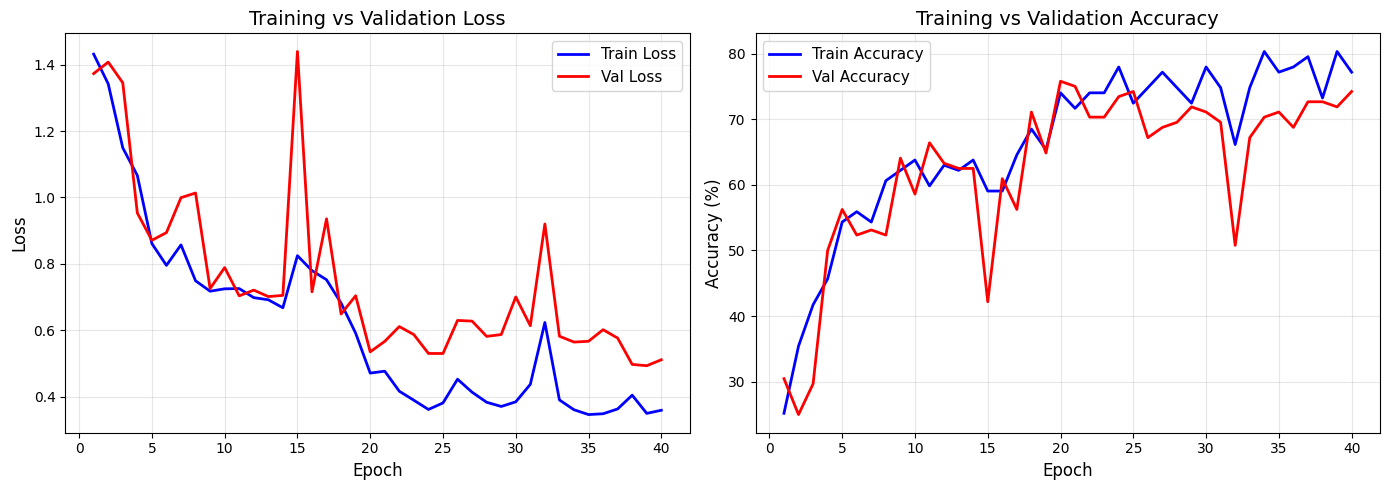

Saved training curves to: C:\NNDL Lab Proj\KTH\training_curves.png


In [54]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, num_epochs + 1)

# Loss plot
ax1.plot(epochs_range, train_losses, 'b-', label='Train Loss', linewidth=2)
ax1.plot(epochs_range, val_losses, 'r-', label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training vs Validation Loss', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(epochs_range, train_accuracies, 'b-', label='Train Accuracy', linewidth=2)
ax2.plot(epochs_range, val_accuracies, 'r-', label='Val Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training vs Validation Accuracy', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(base_dir / "training_curves.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved training curves to: {base_dir / 'training_curves.png'}")

### Test Evaluation

In [55]:
# Load best model
model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
model.eval()

test_dataset = KTHDataset(test_videos, test_labels)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

test_correct = 0
test_total = 0
all_preds = []
all_true = []

with torch.no_grad():
    for videos, labels in test_loader:
        videos = videos.to(device)
        labels = labels.to(device)

        predictions = model(videos)
        predicted = torch.argmax(predictions, dim=1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

test_accuracy = 100 * test_correct / test_total
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Test Correct: {test_correct} / {test_total}")

# Per-class accuracy
print("\nPer-class accuracy:")
for class_id, class_name in enumerate(classes):
    class_mask = [i for i, t in enumerate(all_true) if t == class_id]
    class_correct = sum(1 for i in class_mask if all_preds[i] == class_id)
    class_acc = 100 * class_correct / len(class_mask) if class_mask else 0
    print(f"  {class_name}: {class_acc:.2f}% ({class_correct}/{len(class_mask)})")

# Confusion matrix
print("\nConfusion Matrix:")
print(f"{'':>15}", end="")
for name in classes:
    print(f"{name:>14}", end="")
print()

for true_id, true_name in enumerate(classes):
    print(f"{true_name:>15}", end="")
    for pred_id in range(len(classes)):
        count = sum(1 for t, p in zip(all_true, all_preds)
                    if t == true_id and p == pred_id)
        print(f"{count:>14}", end="")
    print()

# Prediction distribution
print(f"\nPrediction distribution: {Counter(all_preds)}")
print(f"True label distribution: {Counter(all_true)}")

Test Accuracy: 72.92%
Test Correct: 105 / 144

Per-class accuracy:
  walking: 86.11% (31/36)
  running: 94.44% (34/36)
  handwaving: 25.00% (9/36)
  handclapping: 86.11% (31/36)

Confusion Matrix:
                      walking       running    handwaving  handclapping
        walking            31             5             0             0
        running             2            34             0             0
     handwaving             0             0             9            27
   handclapping             0             0             5            31

Prediction distribution: Counter({np.int64(3): 58, np.int64(1): 39, np.int64(0): 33, np.int64(2): 14})
True label distribution: Counter({np.int64(0): 36, np.int64(1): 36, np.int64(2): 36, np.int64(3): 36})


### Individual Video Predictions

In [56]:
model.eval()

# Pick 10 test videos (spread across classes)
sample_indices = []
for class_id in range(4):
    class_idxs = [i for i, lb in enumerate(test_labels) if lb == class_id]
    sample_indices.extend(class_idxs[:3])  # 3 per class = 12 total
sample_indices = sample_indices[:10]

with torch.no_grad():
    for idx in sample_indices:
        video = test_dataset[idx][0].unsqueeze(0).to(device)  # [1, 16, 3, 112, 112]
        true_label = test_labels[idx]

        logits = model(video)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred_label = np.argmax(probs)

        status = "OK" if pred_label == true_label else "WRONG"

        print(f"\n{status} Video: {test_videos[idx].name}")
        print(f"  Actual:    {classes[true_label]} (class {true_label})")
        print(f"  Predicted: {classes[pred_label]} (class {pred_label})")
        print(f"  Probabilities:")
        for ci, cn in enumerate(classes):
            bar = "#" * int(probs[ci] * 30)
            print(f"    {cn:>14}: {probs[ci]:.4f} {bar}")


OK Video: person02_walking_d1_uncomp.avi
  Actual:    walking (class 0)
  Predicted: walking (class 0)
  Probabilities:
           walking: 0.9181 ###########################
           running: 0.0804 ##
        handwaving: 0.0003 
      handclapping: 0.0013 

WRONG Video: person02_walking_d2_uncomp.avi
  Actual:    walking (class 0)
  Predicted: running (class 1)
  Probabilities:
           walking: 0.1793 #####
           running: 0.5947 #################
        handwaving: 0.1192 ###
      handclapping: 0.1068 ###

OK Video: person02_walking_d3_uncomp.avi
  Actual:    walking (class 0)
  Predicted: walking (class 0)
  Probabilities:
           walking: 0.9906 #############################
           running: 0.0026 
        handwaving: 0.0011 
      handclapping: 0.0058 

OK Video: person02_running_d1_uncomp.avi
  Actual:    running (class 1)
  Predicted: running (class 1)
  Probabilities:
           walking: 0.0061 
           running: 0.9926 #############################
      